In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
#from torchinfo import summary

import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from PIL import Image
import numpy as np


In [2]:
seed = 42
torch.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
train_data = pd.read_csv('fashion-mnist_train.csv').fillna(0)

In [4]:
train_data.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,0,0,0,0,0,0,0,5,0,...,0.0,0.0,0.0,30.0,43.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,1,2,0,0,0,0,...,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
X = train_data.iloc[:, 1:].values
y = train_data['label'].values

In [25]:
# Splitting into the training and testing data
X_train, X_test, y_train , y_test = train_test_split(X, y, test_size = 0.2, random_state = seed)

In [89]:
# Transformations
from torchvision.transforms import transforms

custom_transform = transforms.Compose([
		transforms.Resize(256), #	resize → (3, 256, 256)
		transforms.CenterCrop(224),
		transforms.ToTensor(),
		transforms.Normalize(mean=[0.48235, 0.45882, 0.40784], std = [0.00392156862745098, 0.00392156862745098, 0.00392156862745098])
])


In [90]:
from PIL import Image
import numpy as np

class CustomDataset(Dataset):

  def __init__(self, features, labels, transform):
    self.features = features
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):

    # resize to (28, 28)
    image = self.features[index].reshape(28,28)

    # change datatype to np.uint8
    image = image.astype(np.uint8)

    # change black&white to color -> (H,W) -> (H,W,C)
    image = np.stack([image]*3, axis=-1)

    # convert array to PIL image
    image = Image.fromarray(image)

    # apply transforms
    image = self.transform(image)

    # return
    return image, torch.tensor(self.labels[index], dtype=torch.long)

In [91]:
train_dataset = CustomDataset(X_train, y_train, transform = custom_transform)
test_dataset = CustomDataset(X_test, y_test, transform = custom_transform)

train_dataloader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = 32, shuffle = True)


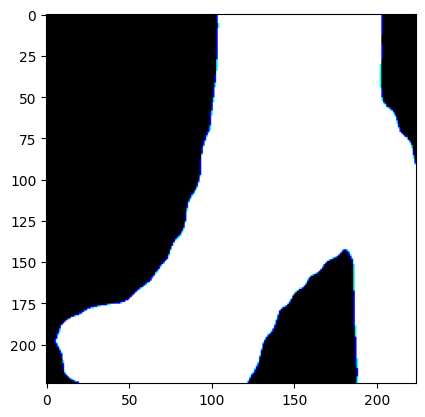

In [107]:
idx =150
image = X_train[idx].reshape(28, 28)
image = image.astype(np.uint8)
image = np.stack([image]*3, axis=-1)
image = Image.fromarray(image)
image = custom_transform(image)
plt.imshow(image.permute(1,2,0), cmap='gray')
# 2. Display the image using matplotlib
#plt.imshow(image, cmap='gray')

In [96]:
# Transfer Learning
import torchvision.models as models

# Takes time to downlaod
vgg16 = models.vgg16(pretrained = True)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 70.6MB/s]


In [97]:
# Provide the convolution extraction features
vgg16.features



Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [98]:
# Provides the classfier architecture
vgg16.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [99]:
for param in vgg16.features.parameters():
  param.requires_grad = False

In [100]:
vgg16.classifier = nn.Sequential(
		nn.Linear(25088, 1024),
		nn.ReLU(),
		nn.Dropout(0.5),
		nn.Linear(1024, 512),
		nn.ReLU(),
		nn.Dropout(0.5),
		nn.Linear(512, 10)
	)

In [101]:
vgg16 = vgg16.to(device)

learning_rate = 0.001
# Takes a lot of time
epochs = 10

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier.parameters(), lr = learning_rate)


In [102]:
for epoch in range(epochs):

  total_epoch_loss = 0

  for features, labels in train_dataloader:

    features, labels = features.to(device), labels.to(device)

    y_pred = vgg16(features)

    loss = criterion(y_pred, labels)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    total_epoch_loss += loss.item()

  avg_loss = total_epoch_loss / len(train_dataloader)
  print(f'Epoch: {epoch+1}, Loss: {avg_loss}')


Epoch: 1, Loss: 2.1204926030257263
Epoch: 2, Loss: 0.8036288197177488
Epoch: 3, Loss: 0.6479114074562047
Epoch: 4, Loss: 0.6444988220527366
Epoch: 5, Loss: 0.5975640355231794
Epoch: 6, Loss: 0.6410277253520247
Epoch: 7, Loss: 0.6428445953674413
Epoch: 8, Loss: 0.609652580517168
Epoch: 9, Loss: 0.6275975430585645
Epoch: 10, Loss: 0.546290690180015


In [103]:
# Set model to eval mode
vgg16.eval()

total, correct = 0,0
with torch.no_grad():
  for batch_features, batch_labels in test_dataloader:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    outputs = vgg16(batch_features)

    # Torch.max gives the prob values, indices
    _ , predicted = torch.max(outputs, 1)

    # Update total entries
    total += batch_labels.shape[0]

    # Update the corrected values
    correct += (predicted == batch_labels).sum().item()

  print(f'Accuracy: {correct / total}')

Accuracy: 0.8568412162162162


In [104]:
# Set model to eval mode
vgg16.eval()

total, correct = 0,0
with torch.no_grad():
  for batch_features, batch_labels in train_dataloader:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    outputs = vgg16(batch_features)

    # Torch.max gives the prob values, indices
    _ , predicted = torch.max(outputs, 1)

    # Update total entries
    total += batch_labels.shape[0]

    # Update the corrected values
    correct += (predicted == batch_labels).sum().item()

  print(f'Accuracy: {correct / total}')

Accuracy: 0.9332699820504698
